# Sleep Detection Cloud AI Experiment

Train binary and multiclass sleep-condition models from engineered physiological features compatible with a MAX30102-based pipeline. The deployable model is the binary sleeping/not-sleeping classifier; the multiclass model is for comparison only.

## 1. Setup and Imports

In [4]:
import importlib
import json
import math
import os
import warnings
from pathlib import Path

missing_packages = []
for package_name in ["datasets", "pyarrow", "pandas", "numpy", "sklearn", "matplotlib", "joblib"]:
    if importlib.util.find_spec(package_name) is None:
        missing_packages.append(package_name)

if missing_packages:
    raise ImportError(
        "Missing required packages: "
        + ", ".join(missing_packages)
        + ". Install them in the notebook environment before running this notebook."
    )

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from IPython.display import display
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
DATASET_ID = "abmallick/heart-breath-sleep-stage-dataset"

# Set either sample limit to None to use all available rows.
TRAIN_SAMPLE_MAX = 300_000
EVAL_SAMPLE_MAX = 300_000

# Gradient boosting and neural networks can be slow on large tabular samples in notebooks.
SLOW_MODEL_SAMPLE_MAX = 120_000

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("Dataset ID:", DATASET_ID)
print("Train sample max:", TRAIN_SAMPLE_MAX)
print("Evaluation sample max:", EVAL_SAMPLE_MAX)

Dataset ID: abmallick/heart-breath-sleep-stage-dataset
Train sample max: 300000
Evaluation sample max: 300000


## 2. Load Dataset

In [5]:
dataset = load_dataset(DATASET_ID)
print(dataset.keys())

dfs = {}

for split_name in dataset.keys():
    dfs[split_name] = dataset[split_name].to_pandas()
    print(split_name, dfs[split_name].shape)

README.md: 0.00B [00:00, ?B/s]

all_nights.parquet:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10633378 [00:00<?, ? examples/s]

dict_keys(['train'])
train (10633378, 16)


## 3. Dataset Overview

In [6]:
if not dfs:
    raise ValueError("No dataset splits were loaded.")

for split_name, df in dfs.items():
    print(f"\nSplit: {split_name}")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    display(df.head())
    display(df.dtypes.to_frame("dtype"))

all_columns = sorted(set().union(*[set(df.columns) for df in dfs.values()]))
print("\nAll observed columns:")
print(all_columns)


Split: train
Shape: (10633378, 16)
Columns: ['time_seconds', 'heart_rate', 'respiratory_rate', 'sleep_stage', 'hr_mean', 'hr_sdnn_5', 'hr_rmssd_5', 'hr_slope_3', 'rr_mean', 'rr_sd_5', 'rr_slope_3', 'hr_rr_ratio', 'hr_rr_product', 'minutes_since_start', 'night_id', 'split']


,time_seconds,heart_rate,respiratory_rate,sleep_stage,hr_mean,hr_sdnn_5,hr_rmssd_5,hr_slope_3,rr_mean,rr_sd_5,rr_slope_3,hr_rr_ratio,hr_rr_product,minutes_since_start,night_id,split
0,0.0,87.42,7.23,5,87.42,0.93,1.31,1.31,7.23,1.45,2.05,12.09,632.05,0.0,1,train
1,30.0,88.73,9.28,5,88.73,0.93,1.31,1.31,9.28,1.45,2.05,9.56,823.41,0.5,1,train
2,60.0,90.29,21.51,5,90.29,1.44,1.44,1.44,21.51,7.72,7.14,4.20,1942.14,1.0,1,train
3,90.0,86.83,27.59,5,86.83,1.54,2.32,-0.20,27.59,9.77,6.79,3.15,2395.64,1.5,1,train
4,120.0,85.86,27.07,5,85.86,1.73,2.07,-0.96,27.07,9.71,5.93,3.17,2324.23,2.0,1,train


,dtype
time_seconds,float64
heart_rate,float64
respiratory_rate,float64
sleep_stage,int64
hr_mean,float64
hr_sdnn_5,float64
hr_rmssd_5,float64
hr_slope_3,float64
rr_mean,float64
rr_sd_5,float64



All observed columns:
['heart_rate', 'hr_mean', 'hr_rmssd_5', 'hr_rr_product', 'hr_rr_ratio', 'hr_sdnn_5', 'hr_slope_3', 'minutes_since_start', 'night_id', 'respiratory_rate', 'rr_mean', 'rr_sd_5', 'rr_slope_3', 'sleep_stage', 'split', 'time_seconds']


## 4. Label Inspection

In [7]:
for split_name, df in dfs.items():
    if "sleep_stage" not in df.columns:
        raise ValueError(f"Required label column 'sleep_stage' is missing from split: {split_name}")
    print(f"\nSplit: {split_name}")
    print(df["sleep_stage"].value_counts(dropna=False).sort_index())

sleep_stage_mapping = {
    0: "Wake",
    1: "N1",
    2: "N2",
    3: "N3",
    5: "REM",
    6: "Movement/Artifact",
    9: "Unknown/Unscored",
}

label_map_df = pd.DataFrame([
    {"sleep_stage": 0, "label": "Wake", "use_for_training": True},
    {"sleep_stage": 1, "label": "N1", "use_for_training": True},
    {"sleep_stage": 2, "label": "N2", "use_for_training": True},
    {"sleep_stage": 3, "label": "N3", "use_for_training": True},
    {"sleep_stage": 5, "label": "REM", "use_for_training": True},
    {"sleep_stage": 6, "label": "Movement/Artifact", "use_for_training": False},
    {"sleep_stage": 9, "label": "Unknown/Unscored", "use_for_training": False},
])
display(label_map_df)


Split: train
sleep_stage
0    3232222
1     505963
2    4269124
3    1179723
5    1446044
6          3
9        299
Name: count, dtype: int64


,sleep_stage,label,use_for_training
0,0,Wake,True
1,1,N1,True
2,2,N2,True
3,3,N3,True
4,5,REM,True
5,6,Movement/Artifact,False
6,9,Unknown/Unscored,False


## 5. Data Cleaning

In [8]:
VALID_SLEEP_STAGES = [0, 1, 2, 3, 5]
EXCLUDED_SLEEP_STAGES = [6, 9]


def normalize_split_name(value):
    if pd.isna(value):
        return np.nan
    normalized = str(value).strip().lower()
    split_aliases = {
        "train": "train",
        "training": "train",
        "val": "validation",
        "valid": "validation",
        "validation": "validation",
        "test": "test",
    }
    return split_aliases.get(normalized, normalized)


def derive_raw_model_splits(input_dfs):
    lower_to_original = {name.lower(): name for name in input_dfs.keys()}
    has_train = "train" in lower_to_original
    validation_key = "validation" if "validation" in lower_to_original else "val" if "val" in lower_to_original else None
    has_test = "test" in lower_to_original

    if has_train and validation_key and has_test:
        return {
            "train": input_dfs[lower_to_original["train"]].copy(),
            "validation": input_dfs[lower_to_original[validation_key]].copy(),
            "test": input_dfs[lower_to_original["test"]].copy(),
        }

    combined_df = pd.concat(input_dfs.values(), axis=0, ignore_index=True)
    if "split" in combined_df.columns:
        split_values = combined_df["split"].map(normalize_split_name)
        observed_splits = sorted([value for value in split_values.dropna().unique()])
        print("Observed internal split values:", observed_splits)
        derived = {}
        for target_split in ["train", "validation", "test"]:
            part = combined_df.loc[split_values == target_split].copy()
            if len(part) > 0:
                derived[target_split] = part.reset_index(drop=True)
        if "train" in derived:
            return derived

    if has_train:
        return {"train": input_dfs[lower_to_original["train"]].copy()}

    first_name = next(iter(input_dfs.keys()))
    print(f"No explicit train split found. Using '{first_name}' as the training source before stratified splitting.")
    return {"train": input_dfs[first_name].copy()}


def clean_sleep_df(df, split_name):
    if "sleep_stage" not in df.columns:
        raise ValueError(f"Required label column 'sleep_stage' is missing from split: {split_name}")

    cleaned = df.copy()
    cleaned["sleep_stage"] = pd.to_numeric(cleaned["sleep_stage"], errors="coerce")
    before_rows = len(cleaned)
    cleaned = cleaned.dropna(subset=["sleep_stage"])
    cleaned["sleep_stage"] = cleaned["sleep_stage"].astype(int)
    cleaned = cleaned[cleaned["sleep_stage"].isin(VALID_SLEEP_STAGES)].copy()
    cleaned = cleaned.replace([np.inf, -np.inf], np.nan)
    cleaned = cleaned.reset_index(drop=True)
    print(f"{split_name}: {before_rows:,} -> {len(cleaned):,} rows after excluding labels {EXCLUDED_SLEEP_STAGES} and missing labels")
    return cleaned


def can_stratify(series):
    counts = series.value_counts(dropna=False)
    return len(counts) > 1 and counts.min() >= 2


def split_dataframe(df, test_size, stratify_col, random_state=RANDOM_STATE):
    stratify = df[stratify_col] if stratify_col in df.columns and can_stratify(df[stratify_col]) else None
    return train_test_split(df, test_size=test_size, random_state=random_state, stratify=stratify)


def ensure_train_validation_test_splits(cleaned_splits):
    if "train" not in cleaned_splits:
        raise ValueError("A training split could not be derived from the dataset.")

    result = {name: df.copy().reset_index(drop=True) for name, df in cleaned_splits.items() if len(df) > 0}

    if "validation" not in result and "test" not in result:
        train_part, holdout_part = split_dataframe(result["train"], test_size=0.30, stratify_col="sleep_stage")
        validation_part, test_part = split_dataframe(holdout_part, test_size=0.50, stratify_col="sleep_stage")
        result["train"] = train_part.reset_index(drop=True)
        result["validation"] = validation_part.reset_index(drop=True)
        result["test"] = test_part.reset_index(drop=True)
    elif "validation" not in result:
        train_part, validation_part = split_dataframe(result["train"], test_size=0.20, stratify_col="sleep_stage")
        result["train"] = train_part.reset_index(drop=True)
        result["validation"] = validation_part.reset_index(drop=True)
    elif "test" not in result:
        train_part, test_part = split_dataframe(result["train"], test_size=0.20, stratify_col="sleep_stage")
        result["train"] = train_part.reset_index(drop=True)
        result["test"] = test_part.reset_index(drop=True)

    return result


raw_model_splits = derive_raw_model_splits(dfs)
cleaned_splits = {split_name: clean_sleep_df(df, split_name) for split_name, df in raw_model_splits.items()}
model_splits = ensure_train_validation_test_splits(cleaned_splits)

train_df = model_splits["train"].copy()
val_df = model_splits["validation"].copy()
test_df = model_splits["test"].copy()

print("\nCleaned modeling split shapes:")
for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(name, df.shape)
    print(df["sleep_stage"].value_counts().sort_index())

Observed internal split values: ['test', 'train', 'validation']
train: 7,442,277 -> 7,442,056 rows after excluding labels [6, 9] and missing labels
validation: 1,600,813 -> 1,600,777 rows after excluding labels [6, 9] and missing labels
test: 1,590,288 -> 1,590,243 rows after excluding labels [6, 9] and missing labels

Cleaned modeling split shapes:
train (7442056, 16)
sleep_stage
0    2256779
1     352338
2    2981832
3     832062
5    1019045
Name: count, dtype: int64
validation (1600777, 16)
sleep_stage
0    489249
1     77738
2    648280
3    171865
5    213645
Name: count, dtype: int64
test (1590243, 16)
sleep_stage
0    486194
1     75887
2    639012
3    175796
5    213354
Name: count, dtype: int64


## 6. Feature Selection

In [9]:
candidate_features = [
    "heart_rate",
    "respiratory_rate",
    "hr_mean",
    "hr_sdnn_5",
    "hr_rmssd_5",
    "hr_slope_3",
    "rr_mean",
    "rr_sd_5",
    "rr_slope_3",
    "hr_rr_ratio",
    "hr_rr_product",
]

leakage_cols = [
    "sleep_stage",
    "is_sleeping",
    "sleep_stage_simplified",
    "night_id",
    "split",
    "classes",
    "class",
    "label",
]

feature_cols = [col for col in candidate_features if col in train_df.columns and col not in leakage_cols]
print("Selected features:", feature_cols)

missing_candidate_features = [col for col in candidate_features if col not in train_df.columns]
if missing_candidate_features:
    print("Candidate features not found in dataset:", missing_candidate_features)

if not feature_cols:
    raise ValueError("No compatible feature columns found in dataset.")

leakage_overlap = sorted(set(feature_cols).intersection(leakage_cols))
if leakage_overlap:
    raise ValueError(f"Leakage columns were selected as features: {leakage_overlap}")

for split_name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    missing_features = [col for col in feature_cols if col not in df.columns]
    if missing_features:
        raise ValueError(f"Split {split_name} is missing selected feature columns: {missing_features}")

Selected features: ['heart_rate', 'respiratory_rate', 'hr_mean', 'hr_sdnn_5', 'hr_rmssd_5', 'hr_slope_3', 'rr_mean', 'rr_sd_5', 'rr_slope_3', 'hr_rr_ratio', 'hr_rr_product']


## 7. Binary Target Processing

In [10]:
binary_mapping = {
    0: 0,
    1: 1,
    2: 1,
    3: 1,
    5: 1,
}

for df in [train_df, val_df, test_df]:
    df["is_sleeping"] = df["sleep_stage"].map(binary_mapping)
    if df["is_sleeping"].isna().any():
        raise ValueError("Binary target contains NaN after mapping. Check sleep_stage filtering.")
    df["is_sleeping"] = df["is_sleeping"].astype(int)

print("Binary label distribution by split:")
for split_name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"\n{split_name}")
    print(df["is_sleeping"].value_counts(normalize=False).sort_index())
    print(df["is_sleeping"].value_counts(normalize=True).sort_index().round(4))

Binary label distribution by split:

train
is_sleeping
0    2256779
1    5185277
Name: count, dtype: int64
is_sleeping
0    0.3032
1    0.6968
Name: proportion, dtype: float64

validation
is_sleeping
0     489249
1    1111528
Name: count, dtype: int64
is_sleeping
0    0.3056
1    0.6944
Name: proportion, dtype: float64

test
is_sleeping
0     486194
1    1104049
Name: count, dtype: int64
is_sleeping
0    0.3057
1    0.6943
Name: proportion, dtype: float64


## 8. Multiclass Target Processing

In [11]:
multiclass_mapping = {
    0: "Wake",
    1: "Light Sleep",
    2: "Light Sleep",
    3: "Deep Sleep",
    5: "REM",
}

multiclass_order = ["Wake", "Light Sleep", "Deep Sleep", "REM"]

for df in [train_df, val_df, test_df]:
    df["sleep_stage_simplified"] = df["sleep_stage"].map(multiclass_mapping)
    if df["sleep_stage_simplified"].isna().any():
        raise ValueError("Multiclass target contains NaN after mapping. Check sleep_stage filtering.")

print("Multiclass label distribution by split:")
for split_name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"\n{split_name}")
    print(df["sleep_stage_simplified"].value_counts().reindex(multiclass_order, fill_value=0))
    print(df["sleep_stage_simplified"].value_counts(normalize=True).reindex(multiclass_order, fill_value=0).round(4))

Multiclass label distribution by split:

train
sleep_stage_simplified
Wake           2256779
Light Sleep    3334170
Deep Sleep      832062
REM            1019045
Name: count, dtype: int64
sleep_stage_simplified
Wake           0.3032
Light Sleep    0.4480
Deep Sleep     0.1118
REM            0.1369
Name: proportion, dtype: float64

validation
sleep_stage_simplified
Wake           489249
Light Sleep    726018
Deep Sleep     171865
REM            213645
Name: count, dtype: int64
sleep_stage_simplified
Wake           0.3056
Light Sleep    0.4535
Deep Sleep     0.1074
REM            0.1335
Name: proportion, dtype: float64

test
sleep_stage_simplified
Wake           486194
Light Sleep    714899
Deep Sleep     175796
REM            213354
Name: count, dtype: int64
sleep_stage_simplified
Wake           0.3057
Light Sleep    0.4496
Deep Sleep     0.1105
REM            0.1342
Name: proportion, dtype: float64


## 9. Train/Validation/Test Preparation

In [12]:
def stratified_sample_df(df, target_col, max_rows, random_state=RANDOM_STATE):
    if max_rows is None or len(df) <= max_rows:
        return df.copy().reset_index(drop=True)
    stratify = df[target_col] if can_stratify(df[target_col]) else None
    sampled, _ = train_test_split(
        df,
        train_size=max_rows,
        random_state=random_state,
        stratify=stratify,
    )
    return sampled.reset_index(drop=True)


train_fit_df = stratified_sample_df(train_df, "sleep_stage", TRAIN_SAMPLE_MAX)
val_eval_df = stratified_sample_df(val_df, "sleep_stage", EVAL_SAMPLE_MAX)
test_eval_df = stratified_sample_df(test_df, "sleep_stage", EVAL_SAMPLE_MAX)

slow_train_fit_df = stratified_sample_df(train_fit_df, "sleep_stage", SLOW_MODEL_SAMPLE_MAX)

X_train = train_fit_df[feature_cols]
X_val = val_eval_df[feature_cols]
X_test = test_eval_df[feature_cols]

y_train_binary = train_fit_df["is_sleeping"]
y_val_binary = val_eval_df["is_sleeping"]
y_test_binary = test_eval_df["is_sleeping"]

y_train_multiclass = train_fit_df["sleep_stage_simplified"]
y_val_multiclass = val_eval_df["sleep_stage_simplified"]
y_test_multiclass = test_eval_df["sleep_stage_simplified"]

X_train_slow = slow_train_fit_df[feature_cols]
y_train_slow_binary = slow_train_fit_df["is_sleeping"]
y_train_slow_multiclass = slow_train_fit_df["sleep_stage_simplified"]

print("Training feature shape:", X_train.shape)
print("Validation feature shape:", X_val.shape)
print("Test feature shape:", X_test.shape)
print("Slow-model training feature shape:", X_train_slow.shape)

if "night_id" in train_df.columns:
    print("night_id is present and reserved only for leakage analysis; it is not used as a feature.")
    print("Train nights:", train_df["night_id"].nunique())
    print("Validation nights:", val_df["night_id"].nunique())
    print("Test nights:", test_df["night_id"].nunique())

Training feature shape: (300000, 11)
Validation feature shape: (300000, 11)
Test feature shape: (300000, 11)
Slow-model training feature shape: (120000, 11)
night_id is present and reserved only for leakage analysis; it is not used as a feature.
Train nights: 7240
Validation nights: 1551
Test nights: 1551


## 10. Exploratory Data Analysis

Cleaned split shapes:


,split,rows,columns
0,train,7442056,18
1,validation,1600777,18
2,test,1590243,18


Selected feature columns:
['heart_rate', 'respiratory_rate', 'hr_mean', 'hr_sdnn_5', 'hr_rmssd_5', 'hr_slope_3', 'rr_mean', 'rr_sd_5', 'rr_slope_3', 'hr_rr_ratio', 'hr_rr_product']
Missing values in selected features:


,train_missing,validation_missing,test_missing
heart_rate,0,0,0
respiratory_rate,0,0,0
hr_mean,0,0,0
hr_sdnn_5,0,0,0
hr_rmssd_5,0,0,0
hr_slope_3,0,0,0
rr_mean,0,0,0
rr_sd_5,0,0,0
rr_slope_3,0,0,0
hr_rr_ratio,0,0,0


Descriptive statistics from training split:


,count,mean,std,min,25%,50%,75%,max
heart_rate,7442056.0,70.688291,18.210881,30.00,59.37,66.57,76.06,214.09
respiratory_rate,7442056.0,20.745607,7.610612,4.00,14.86,18.55,26.87,50.00
hr_mean,7442056.0,70.688291,18.210881,30.00,59.37,66.57,76.06,214.09
hr_sdnn_5,7442056.0,2.469018,3.252219,0.00,0.73,1.37,2.73,59.17
hr_rmssd_5,7442056.0,3.107234,3.944985,0.00,0.94,1.78,3.54,72.91
hr_slope_3,7442056.0,0.020332,2.172743,-58.97,-0.50,-0.01,0.47,61.15
rr_mean,7442056.0,20.745607,7.610612,4.00,14.86,18.55,26.87,50.00
rr_sd_5,7442056.0,2.385257,1.771776,0.00,0.93,2.05,3.42,25.12
rr_slope_3,7442056.0,0.003083,1.440058,-27.53,-0.61,0.00,0.61,35.53
hr_rr_ratio,7442056.0,3.871492,1.764108,0.70,2.63,3.68,4.64,36.62


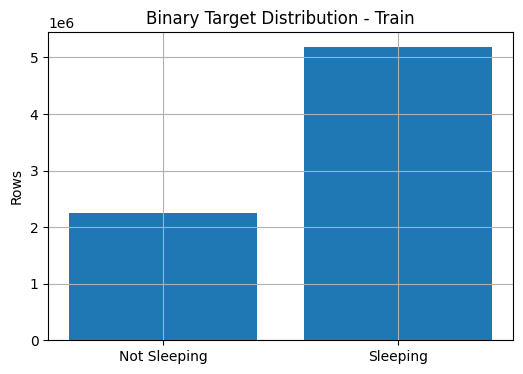

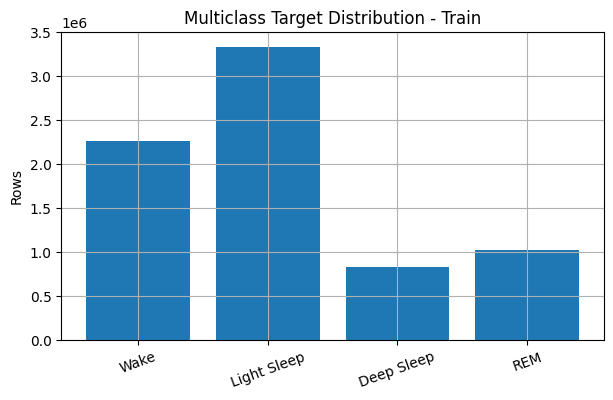

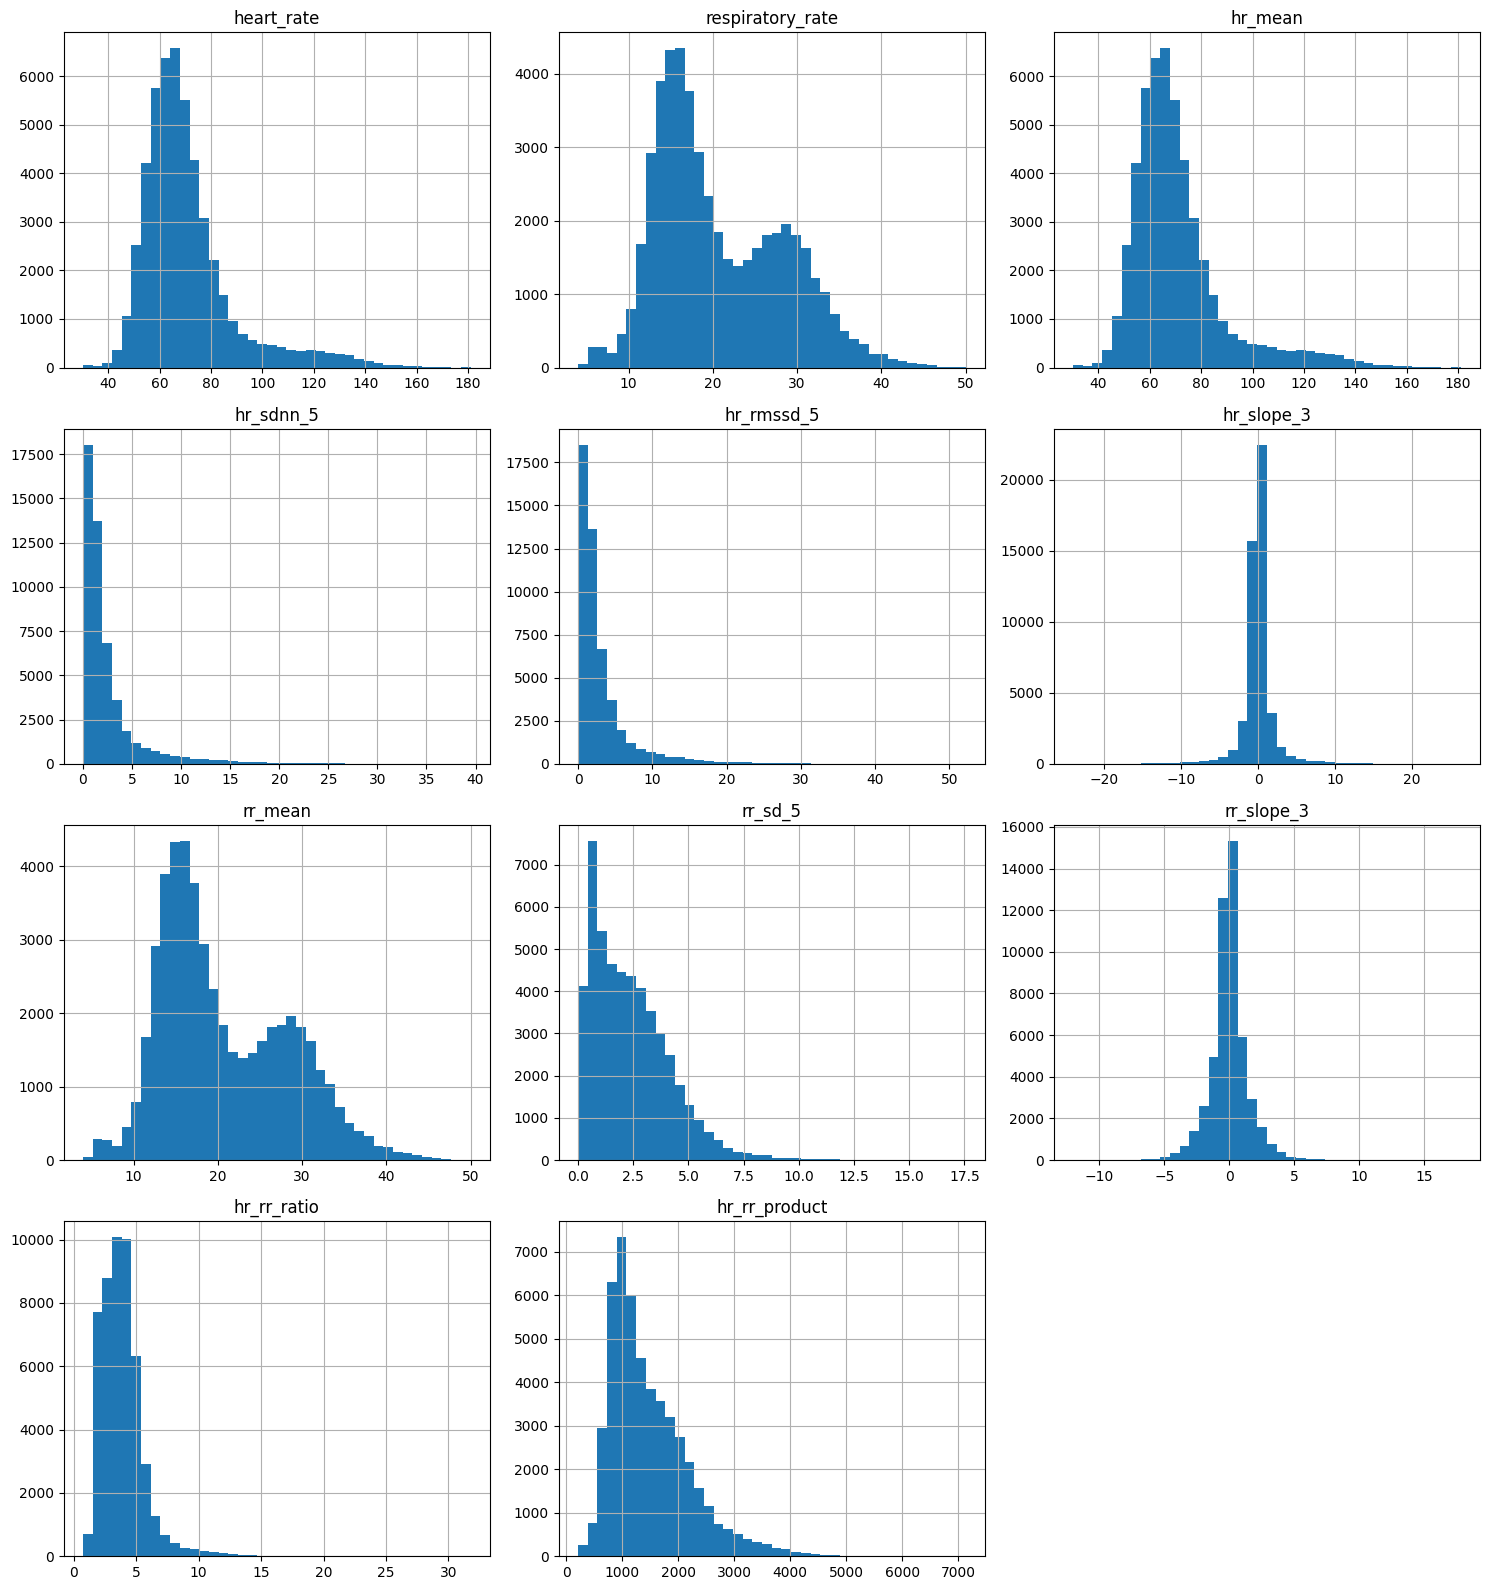

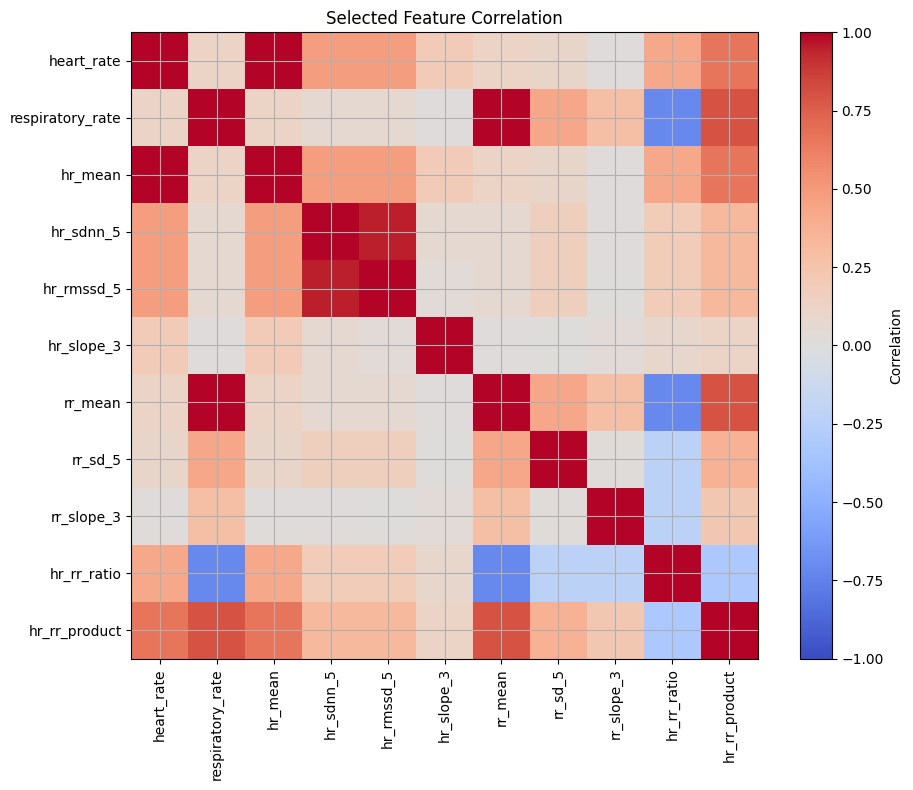

In [13]:
print("Cleaned split shapes:")
display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "columns": [train_df.shape[1], val_df.shape[1], test_df.shape[1]],
}))

print("Selected feature columns:")
print(feature_cols)

print("Missing values in selected features:")
missing_summary = pd.DataFrame({
    "train_missing": train_df[feature_cols].isna().sum(),
    "validation_missing": val_df[feature_cols].isna().sum(),
    "test_missing": test_df[feature_cols].isna().sum(),
})
display(missing_summary)

print("Descriptive statistics from training split:")
display(train_df[feature_cols].describe().T)

binary_counts = train_df["is_sleeping"].value_counts().sort_index()
binary_labels = ["Not Sleeping", "Sleeping"]
plt.figure(figsize=(6, 4))
plt.bar(binary_labels, binary_counts.reindex([0, 1], fill_value=0).values)
plt.title("Binary Target Distribution - Train")
plt.ylabel("Rows")
plt.show()

multiclass_counts = train_df["sleep_stage_simplified"].value_counts().reindex(multiclass_order, fill_value=0)
plt.figure(figsize=(7, 4))
plt.bar(multiclass_counts.index, multiclass_counts.values)
plt.title("Multiclass Target Distribution - Train")
plt.ylabel("Rows")
plt.xticks(rotation=20)
plt.show()

plot_df = stratified_sample_df(train_df, "sleep_stage", min(50_000, len(train_df)))
n_features = len(feature_cols)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).reshape(-1)
for ax, feature in zip(axes, feature_cols):
    ax.hist(plot_df[feature].dropna(), bins=40)
    ax.set_title(feature)
for ax in axes[n_features:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

corr = plot_df[feature_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(feature_cols)), feature_cols, rotation=90)
plt.yticks(range(len(feature_cols)), feature_cols)
plt.title("Selected Feature Correlation")
plt.tight_layout()
plt.show()

## 11. Baseline Models

In [14]:
def make_imputed_pipeline(estimator):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", estimator),
    ])


def make_scaled_pipeline(estimator):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", estimator),
    ])


baseline_model_specs = {
    "DummyClassifier": {
        "model": make_imputed_pipeline(DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)),
        "slow": False,
    },
    "LogisticRegression": {
        "model": make_scaled_pipeline(LogisticRegression(max_iter=1_000, class_weight="balanced", random_state=RANDOM_STATE)),
        "slow": False,
    },
}

print("Baseline models:")
print(list(baseline_model_specs.keys()))

Baseline models:
['DummyClassifier', 'LogisticRegression']


## 12. Better Models

In [15]:
better_model_specs = {
    "RandomForestClassifier": {
        "model": make_imputed_pipeline(RandomForestClassifier(
            n_estimators=200,
            max_depth=18,
            min_samples_leaf=5,
            n_jobs=-1,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
        )),
        "slow": False,
    },
    "HistGradientBoostingClassifier": {
        "model": make_imputed_pipeline(HistGradientBoostingClassifier(
            max_iter=150,
            learning_rate=0.08,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE,
        )),
        "slow": False,
    },
    "GradientBoostingClassifier": {
        "model": make_imputed_pipeline(GradientBoostingClassifier(
            n_estimators=80,
            learning_rate=0.07,
            max_depth=3,
            subsample=0.8,
            random_state=RANDOM_STATE,
        )),
        "slow": True,
    },
}

try:
    from xgboost import XGBClassifier

    better_model_specs["XGBoostClassifier"] = {
        "model": make_imputed_pipeline(XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=RANDOM_STATE,
        )),
        "slow": False,
        "binary_only": True,
    }
except Exception as exc:
    print("XGBoost not available; skipping optional XGBoost model.", exc)

try:
    from lightgbm import LGBMClassifier

    better_model_specs["LightGBMClassifier"] = {
        "model": make_imputed_pipeline(LGBMClassifier(
            n_estimators=250,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )),
        "slow": False,
    }
except Exception as exc:
    print("LightGBM not available; skipping optional LightGBM model.", exc)

print("Better models:")
print(list(better_model_specs.keys()))

Better models:
['RandomForestClassifier', 'HistGradientBoostingClassifier', 'GradientBoostingClassifier', 'XGBoostClassifier', 'LightGBMClassifier']


## 13. Advanced Models

In [16]:
advanced_model_specs = {
    "MLPClassifier": {
        "model": make_scaled_pipeline(MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            alpha=1e-4,
            batch_size=1024,
            learning_rate_init=1e-3,
            max_iter=80,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=8,
            random_state=RANDOM_STATE,
        )),
        "slow": True,
    },
}

all_model_specs = {}
all_model_specs.update(baseline_model_specs)
all_model_specs.update(better_model_specs)
all_model_specs.update(advanced_model_specs)

print("All configured models:")
print(list(all_model_specs.keys()))

All configured models:
['DummyClassifier', 'LogisticRegression', 'RandomForestClassifier', 'HistGradientBoostingClassifier', 'GradientBoostingClassifier', 'XGBoostClassifier', 'LightGBMClassifier', 'MLPClassifier']


## 14. Binary Model Evaluation

In [17]:
def get_positive_scores(model, X, positive_label=1):
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X)
        classes = list(getattr(model, "classes_", []))
        if positive_label in classes:
            return probabilities[:, classes.index(positive_label)]
        if probabilities.shape[1] > 1:
            return probabilities[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        if np.ndim(scores) == 1:
            return scores
    return None


def binary_metrics(model, X, y_true):
    y_pred = model.predict(X)
    scores = get_positive_scores(model, X)
    if scores is not None and len(np.unique(y_true)) == 2:
        roc_auc = roc_auc_score(y_true, scores)
    else:
        roc_auc = np.nan
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc,
    }


def fit_and_evaluate_binary_models(model_specs):
    rows = []
    trained_models = {}
    for model_name, spec in model_specs.items():
        model = clone(spec["model"])
        fit_X = X_train_slow if spec.get("slow", False) else X_train
        fit_y = y_train_slow_binary if spec.get("slow", False) else y_train_binary
        try:
            print(f"Training binary model: {model_name} on {len(fit_X):,} rows")
            model.fit(fit_X, fit_y)
            metrics = binary_metrics(model, X_val, y_val_binary)
            rows.append({"model_name": model_name, **metrics})
            trained_models[model_name] = model
        except Exception as exc:
            print(f"Skipping binary model {model_name}: {exc}")
    results = pd.DataFrame(rows)
    if results.empty:
        raise ValueError("No binary models were trained successfully.")
    results = results.sort_values(["f1", "roc_auc"], ascending=False, na_position="last").reset_index(drop=True)
    return results, trained_models


binary_results_df, binary_trained_models = fit_and_evaluate_binary_models(all_model_specs)
display(binary_results_df)

best_binary_model_name = binary_results_df.iloc[0]["model_name"]
best_binary_model = binary_trained_models[best_binary_model_name]
print("Best binary model:", best_binary_model_name)

binary_test_pred = best_binary_model.predict(X_test)
print("Binary test confusion matrix:")
print(confusion_matrix(y_test_binary, binary_test_pred, labels=[0, 1]))
print("\nBinary test classification report:")
print(classification_report(y_test_binary, binary_test_pred, target_names=["Not Sleeping", "Sleeping"], zero_division=0))

Training binary model: DummyClassifier on 300,000 rows
Training binary model: LogisticRegression on 300,000 rows
Training binary model: RandomForestClassifier on 300,000 rows
Training binary model: HistGradientBoostingClassifier on 300,000 rows
Training binary model: GradientBoostingClassifier on 120,000 rows
Training binary model: XGBoostClassifier on 300,000 rows
Training binary model: LightGBMClassifier on 300,000 rows
Training binary model: MLPClassifier on 120,000 rows


,model_name,accuracy,precision,recall,f1,roc_auc
0,XGBoostClassifier,0.775190,0.787929,0.925275,0.851097,0.781308
1,HistGradientBoostingClassifier,0.775050,0.787655,0.925558,0.851056,0.781374
2,GradientBoostingClassifier,0.771663,0.785844,0.922577,0.848739,0.774160
3,MLPClassifier,0.770760,0.783349,0.925947,0.848700,0.770765
4,RandomForestClassifier,0.751287,0.814209,0.831564,0.822795,0.776360
5,DummyClassifier,0.694367,0.694367,1.000000,0.819618,0.500000
6,LogisticRegression,0.738707,0.805825,0.821694,0.813682,0.750240
7,LightGBMClassifier,0.727753,0.831348,0.762633,0.795509,0.781342


Best binary model: XGBoostClassifier
Binary test confusion matrix:
[[ 38519  53202]
 [ 14377 193902]]

Binary test classification report:
              precision    recall  f1-score   support

Not Sleeping       0.73      0.42      0.53     91721
    Sleeping       0.78      0.93      0.85    208279

    accuracy                           0.77    300000
   macro avg       0.76      0.68      0.69    300000
weighted avg       0.77      0.77      0.75    300000



## 15. Multiclass Model Evaluation

In [18]:
def multiclass_metrics(model, X, y_true):
    y_pred = model.predict(X)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def fit_and_evaluate_multiclass_models(model_specs):
    rows = []
    trained_models = {}
    for model_name, spec in model_specs.items():
        if spec.get("binary_only", False):
            continue
        model = clone(spec["model"])
        fit_X = X_train_slow if spec.get("slow", False) else X_train
        fit_y = y_train_slow_multiclass if spec.get("slow", False) else y_train_multiclass
        try:
            print(f"Training multiclass model: {model_name} on {len(fit_X):,} rows")
            model.fit(fit_X, fit_y)
            metrics = multiclass_metrics(model, X_val, y_val_multiclass)
            rows.append({"model_name": model_name, **metrics})
            trained_models[model_name] = model
        except Exception as exc:
            print(f"Skipping multiclass model {model_name}: {exc}")
    results = pd.DataFrame(rows)
    if results.empty:
        raise ValueError("No multiclass models were trained successfully.")
    results = results.sort_values(["macro_f1", "weighted_f1"], ascending=False).reset_index(drop=True)
    return results, trained_models


multiclass_results_df, multiclass_trained_models = fit_and_evaluate_multiclass_models(all_model_specs)
display(multiclass_results_df)

best_multiclass_model_name = multiclass_results_df.iloc[0]["model_name"]
best_multiclass_model = multiclass_trained_models[best_multiclass_model_name]
print("Best multiclass model:", best_multiclass_model_name)

multiclass_test_pred = best_multiclass_model.predict(X_test)
print("Multiclass test confusion matrix:")
print(confusion_matrix(y_test_multiclass, multiclass_test_pred, labels=multiclass_order))
print("\nMulticlass test classification report:")
print(classification_report(y_test_multiclass, multiclass_test_pred, labels=multiclass_order, zero_division=0))

Training multiclass model: DummyClassifier on 300,000 rows
Training multiclass model: LogisticRegression on 300,000 rows
Training multiclass model: RandomForestClassifier on 300,000 rows
Training multiclass model: HistGradientBoostingClassifier on 300,000 rows
Training multiclass model: GradientBoostingClassifier on 120,000 rows
Training multiclass model: LightGBMClassifier on 300,000 rows
Training multiclass model: MLPClassifier on 120,000 rows


,model_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RandomForestClassifier,0.449140,0.433806,0.464569,0.426205,0.465966
1,LightGBMClassifier,0.392437,0.437492,0.481523,0.390709,0.396367
2,LogisticRegression,0.359697,0.401276,0.438245,0.354283,0.368465
3,HistGradientBoostingClassifier,0.562603,0.500138,0.363769,0.333614,0.490893
4,MLPClassifier,0.558487,0.472088,0.357265,0.320496,0.482581
5,GradientBoostingClassifier,0.559013,0.507944,0.356424,0.320197,0.482178
6,DummyClassifier,0.453540,0.113385,0.250000,0.156012,0.283031


Best multiclass model: RandomForestClassifier
Multiclass test confusion matrix:
[[46259 15016  6589 23857]
 [16063 52155 31347 35301]
 [ 2277 11966 15289  3632]
 [ 7836  9940  2598 19875]]

Multiclass test classification report:
              precision    recall  f1-score   support

        Wake       0.64      0.50      0.56     91721
 Light Sleep       0.59      0.39      0.47    134866
  Deep Sleep       0.27      0.46      0.34     33164
         REM       0.24      0.49      0.32     40249

    accuracy                           0.45    300000
   macro avg       0.43      0.46      0.42    300000
weighted avg       0.52      0.45      0.46    300000



## 16. Model Comparison

Binary model comparison on validation set:


,model_name,accuracy,precision,recall,f1,roc_auc
0,XGBoostClassifier,0.775190,0.787929,0.925275,0.851097,0.781308
1,HistGradientBoostingClassifier,0.775050,0.787655,0.925558,0.851056,0.781374
2,GradientBoostingClassifier,0.771663,0.785844,0.922577,0.848739,0.774160
3,MLPClassifier,0.770760,0.783349,0.925947,0.848700,0.770765
4,RandomForestClassifier,0.751287,0.814209,0.831564,0.822795,0.776360
5,DummyClassifier,0.694367,0.694367,1.000000,0.819618,0.500000
6,LogisticRegression,0.738707,0.805825,0.821694,0.813682,0.750240
7,LightGBMClassifier,0.727753,0.831348,0.762633,0.795509,0.781342


Multiclass model comparison on validation set:


,model_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RandomForestClassifier,0.449140,0.433806,0.464569,0.426205,0.465966
1,LightGBMClassifier,0.392437,0.437492,0.481523,0.390709,0.396367
2,LogisticRegression,0.359697,0.401276,0.438245,0.354283,0.368465
3,HistGradientBoostingClassifier,0.562603,0.500138,0.363769,0.333614,0.490893
4,MLPClassifier,0.558487,0.472088,0.357265,0.320496,0.482581
5,GradientBoostingClassifier,0.559013,0.507944,0.356424,0.320197,0.482178
6,DummyClassifier,0.453540,0.113385,0.250000,0.156012,0.283031


,task,best_model,selection_metric,validation_score
0,binary,XGBoostClassifier,f1 then roc_auc,0.851097
1,multiclass,RandomForestClassifier,macro_f1 then weighted_f1,0.426205


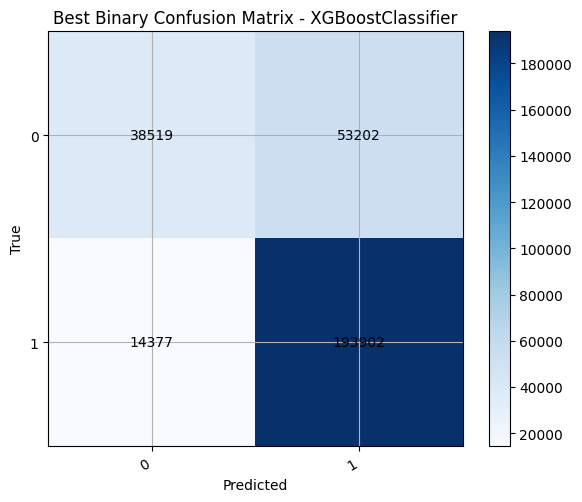

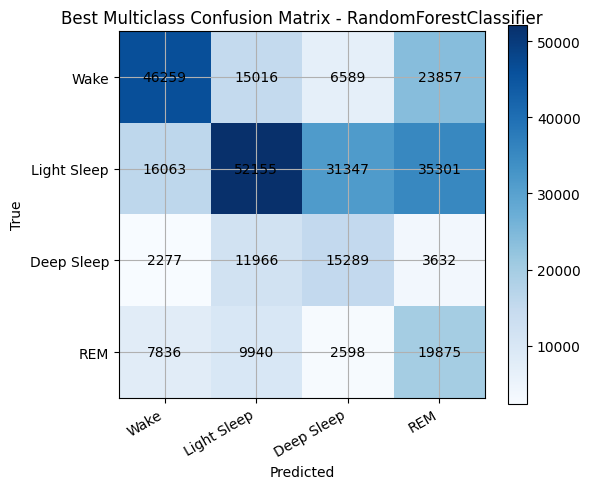

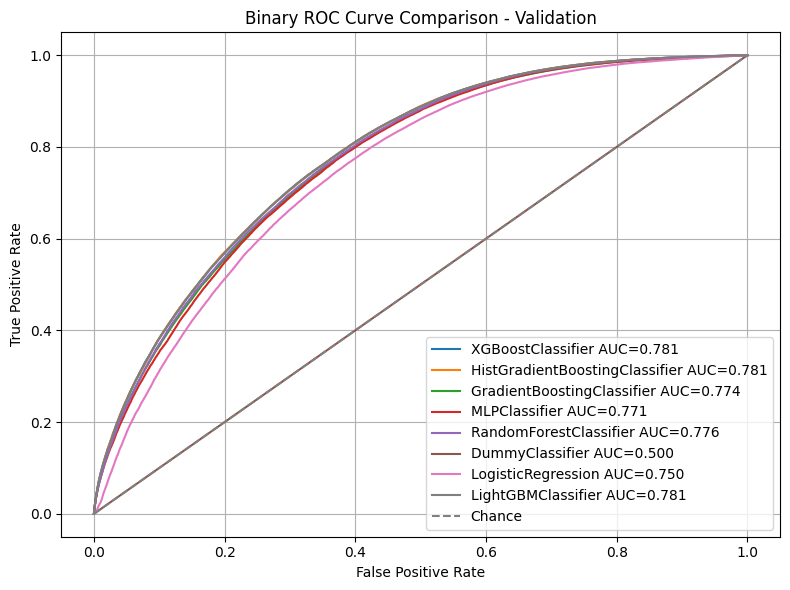

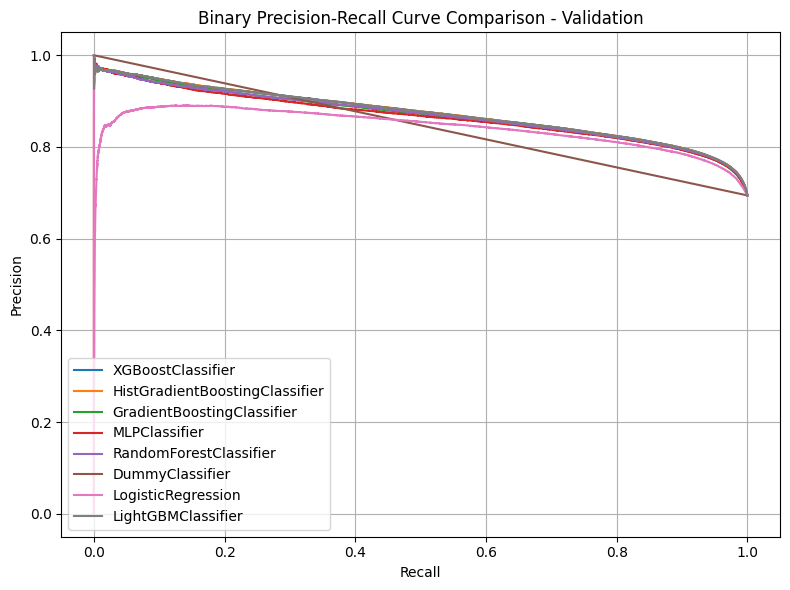

In [19]:
print("Binary model comparison on validation set:")
display(binary_results_df)

print("Multiclass model comparison on validation set:")
display(multiclass_results_df)

comparison_summary = pd.DataFrame([
    {
        "task": "binary",
        "best_model": best_binary_model_name,
        "selection_metric": "f1 then roc_auc",
        "validation_score": binary_results_df.iloc[0]["f1"],
    },
    {
        "task": "multiclass",
        "best_model": best_multiclass_model_name,
        "selection_metric": "macro_f1 then weighted_f1",
        "validation_score": multiclass_results_df.iloc[0]["macro_f1"],
    },
])
display(comparison_summary)


def plot_confusion_matrix_from_predictions(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(cm, cmap="Blues")
    fig.colorbar(image, ax=ax)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix_from_predictions(
    y_test_binary,
    binary_test_pred,
    labels=[0, 1],
    title=f"Best Binary Confusion Matrix - {best_binary_model_name}",
)

plot_confusion_matrix_from_predictions(
    y_test_multiclass,
    multiclass_test_pred,
    labels=multiclass_order,
    title=f"Best Multiclass Confusion Matrix - {best_multiclass_model_name}",
)

plt.figure(figsize=(8, 6))
for model_name in binary_results_df["model_name"]:
    model = binary_trained_models[model_name]
    scores = get_positive_scores(model, X_val)
    if scores is None or len(np.unique(y_val_binary)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_val_binary, scores)
    plt.plot(fpr, tpr, label=f"{model_name} AUC={auc(fpr, tpr):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Binary ROC Curve Comparison - Validation")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for model_name in binary_results_df["model_name"]:
    model = binary_trained_models[model_name]
    scores = get_positive_scores(model, X_val)
    if scores is None:
        continue
    precision, recall, _ = precision_recall_curve(y_val_binary, scores)
    plt.plot(recall, precision, label=model_name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Binary Precision-Recall Curve Comparison - Validation")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 17. Feature Importance

Feature importance model: XGBoostClassifier


,feature,importance
3,hr_sdnn_5,0.394662
4,hr_rmssd_5,0.135814
0,heart_rate,0.116355
2,hr_mean,0.099681
7,rr_sd_5,0.064325
6,rr_mean,0.045179
1,respiratory_rate,0.041355
9,hr_rr_ratio,0.039438
5,hr_slope_3,0.028918
10,hr_rr_product,0.017807


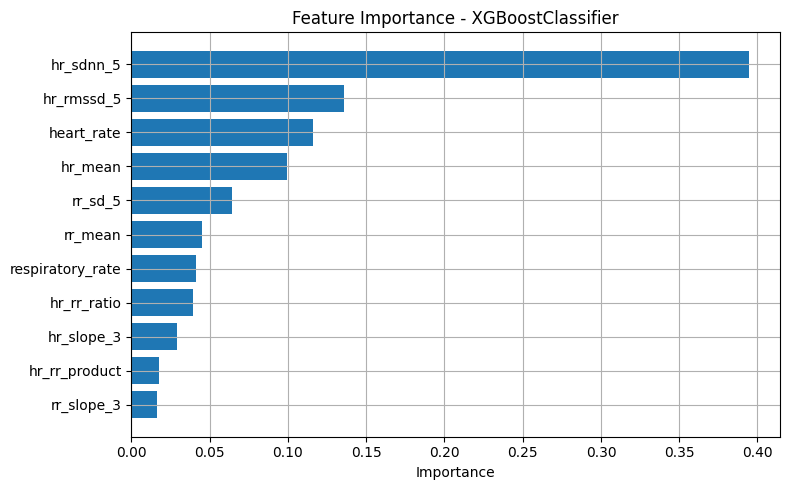

Best binary model importance or coefficient magnitude:


,feature,importance
3,hr_sdnn_5,0.394662
4,hr_rmssd_5,0.135814
0,heart_rate,0.116355
2,hr_mean,0.099681
7,rr_sd_5,0.064325
6,rr_mean,0.045179
1,respiratory_rate,0.041355
9,hr_rr_ratio,0.039438
5,hr_slope_3,0.028918
10,hr_rr_product,0.017807


In [20]:
def final_estimator(model):
    if isinstance(model, Pipeline):
        return model.named_steps.get("classifier")
    return model


def extract_feature_importances(model):
    estimator = final_estimator(model)
    if hasattr(estimator, "feature_importances_"):
        values = estimator.feature_importances_
    elif hasattr(estimator, "coef_") and np.ndim(estimator.coef_) == 2:
        values = np.mean(np.abs(estimator.coef_), axis=0)
    else:
        return None
    return pd.DataFrame({"feature": feature_cols, "importance": values}).sort_values("importance", ascending=False)


tree_importance_df = None
tree_importance_model_name = None
tree_model_keywords = ["RandomForest", "GradientBoosting", "LightGBM", "XGBoost"]

for model_name in binary_results_df["model_name"]:
    if not any(keyword in model_name for keyword in tree_model_keywords):
        continue
    importances = extract_feature_importances(binary_trained_models[model_name])
    if importances is not None:
        tree_importance_df = importances
        tree_importance_model_name = model_name
        break

if tree_importance_df is not None:
    print("Feature importance model:", tree_importance_model_name)
    display(tree_importance_df)
    plt.figure(figsize=(8, 5))
    plt.barh(tree_importance_df["feature"], tree_importance_df["importance"])
    plt.gca().invert_yaxis()
    plt.xlabel("Importance")
    plt.title(f"Feature Importance - {tree_importance_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print("No tree-based model with feature_importances_ was available.")

best_binary_importance_df = extract_feature_importances(best_binary_model)
if best_binary_importance_df is not None:
    print("Best binary model importance or coefficient magnitude:")
    display(best_binary_importance_df)

## 18. Export Best Models

In [21]:
EXPORT_DIR = Path.cwd()
print("Export directory:", EXPORT_DIR.resolve())

binary_model_path = EXPORT_DIR / "sleep_detection_binary_model.joblib"
multiclass_model_path = EXPORT_DIR / "sleep_stage_multiclass_model.joblib"
feature_columns_path = EXPORT_DIR / "sleep_detection_feature_columns.joblib"
metadata_path = EXPORT_DIR / "sleep_detection_model_metadata.json"

joblib.dump(best_binary_model, binary_model_path)
joblib.dump(best_multiclass_model, multiclass_model_path)
joblib.dump(feature_cols, feature_columns_path)

metadata = {
    "dataset_id": DATASET_ID,
    "feature_cols": feature_cols,
    "best_binary_model_name": best_binary_model_name,
    "best_multiclass_model_name": best_multiclass_model_name,
    "binary_mapping": {
        0: "Not Sleeping",
        1: "Sleeping",
    },
    "multiclass_mapping": {
        0: "Wake",
        1: "Light Sleep",
        2: "Deep Sleep",
        3: "REM",
    },
    "sleep_stage_mapping": sleep_stage_mapping,
    "excluded_sleep_stage_values": EXCLUDED_SLEEP_STAGES,
    "train_sample_max": TRAIN_SAMPLE_MAX,
    "eval_sample_max": EVAL_SAMPLE_MAX,
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Exported files:")
for path in [binary_model_path, multiclass_model_path, feature_columns_path, metadata_path]:
    print(path.resolve())

Export directory: D:\Code\Informatika\Semester 8\IOT\model\edge ai\prediction\sleep detection
Exported files:
D:\Code\Informatika\Semester 8\IOT\model\edge ai\prediction\sleep detection\sleep_detection_binary_model.joblib
D:\Code\Informatika\Semester 8\IOT\model\edge ai\prediction\sleep detection\sleep_stage_multiclass_model.joblib
D:\Code\Informatika\Semester 8\IOT\model\edge ai\prediction\sleep detection\sleep_detection_feature_columns.joblib
D:\Code\Informatika\Semester 8\IOT\model\edge ai\prediction\sleep detection\sleep_detection_model_metadata.json


## 19. Sample Inference Function

In [22]:
def predict_sleep(sample_dict, model=best_binary_model, feature_cols=feature_cols):
    sample_df = pd.DataFrame([sample_dict])

    missing_cols = [col for col in feature_cols if col not in sample_df.columns]
    if missing_cols:
        raise ValueError(f"Missing required feature columns: {missing_cols}")

    sample_df = sample_df[feature_cols]

    pred = model.predict(sample_df)[0]

    result = {
        "is_sleeping": int(pred),
        "label": "Sleeping" if int(pred) == 1 else "Not Sleeping",
    }

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(sample_df)[0]
        classes = list(getattr(model, "classes_", []))
        if 1 in classes:
            result["sleep_probability"] = float(proba[classes.index(1)])
        elif len(proba) > 1:
            result["sleep_probability"] = float(proba[1])

    return result


full_sample = {
    "heart_rate": 78,
    "respiratory_rate": 16.2,
    "hr_mean": 76.5,
    "hr_sdnn_5": 42.1,
    "hr_rmssd_5": 35.8,
    "hr_slope_3": -0.4,
    "rr_mean": 15.8,
    "rr_sd_5": 2.1,
    "rr_slope_3": -0.2,
    "hr_rr_ratio": 4.8,
    "hr_rr_product": 1236.0,
}

sample = {col: full_sample[col] for col in feature_cols if col in full_sample}
print("Sample fields used:", sample)
predict_sleep(sample)

Sample fields used: {'heart_rate': 78, 'respiratory_rate': 16.2, 'hr_mean': 76.5, 'hr_sdnn_5': 42.1, 'hr_rmssd_5': 35.8, 'hr_slope_3': -0.4, 'rr_mean': 15.8, 'rr_sd_5': 2.1, 'rr_slope_3': -0.2, 'hr_rr_ratio': 4.8, 'hr_rr_product': 1236.0}


{'is_sleeping': 0,
 'label': 'Not Sleeping',
 'sleep_probability': 0.2562175989151001}